**NIT6004 Project 1: Neural Network and Deep Learning**



Image classification with different opitimizers

**Import Libraries**

In [ ]:
#MNIST digits dataset
#Step 1 : Importing required Libraries
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Import Dataset**

In [ ]:
from keras.datasets import mnist
#Step 2: Importing the MNIST Digit Dataset
#Dividing the dataset into test & train
keras.datasets.mnist.load_data(path="mnist.npz")
mnist = keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [ ]:
#SCaling the dataset from 0- 255 to 0 & 1
x_valid, x_train = x_train[:5000] / 255.0, x_train[5000:] / 255.
y_valid, y_train = y_train[:5000], y_train[5000:]
x_test = x_test / 255.0

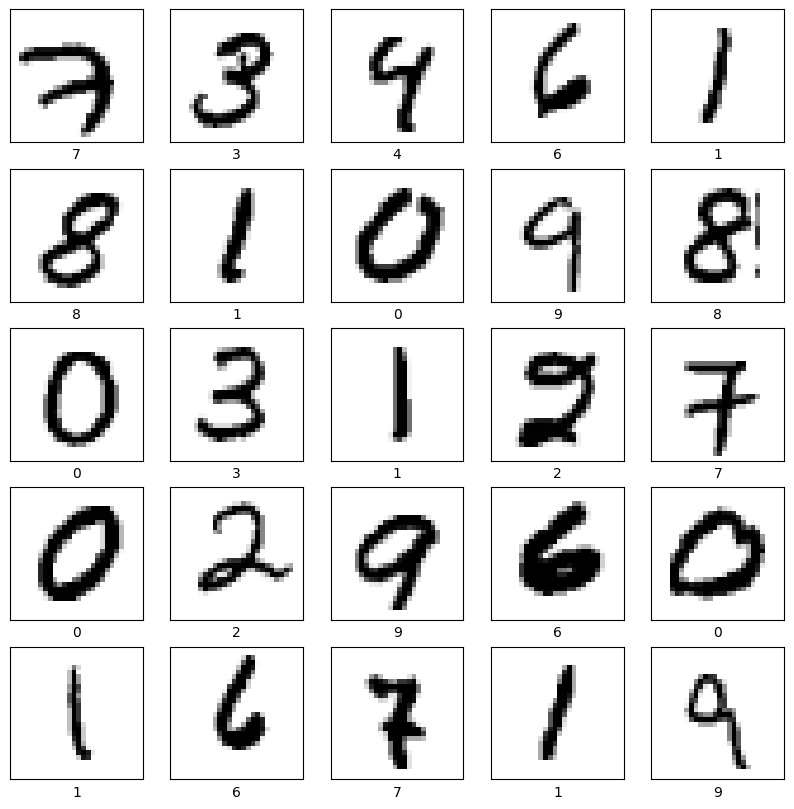

In [ ]:
##Checking the plot
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
plt.show()

# **Build a Classifier using** **MLP**

In [ ]:
#Step 3:Build a Classifier using MLP
##As we can see i'm using Rectified Linear unit & Softmax activation fucntion
from tensorflow import keras
from tensorflow.keras import layers

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[28, 28]))
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

# **Compile the Model**

In [ ]:
#Step 4: Compiling the model with the given parameters
optimizers = ["sgd", "rmsprop","adam"]
models = {}

for opt in optimizers:
  model = tf.keras.models.Sequential()
  model.add(tf.keras.layers.Flatten(input_shape=[28, 28]))
  model.add(tf.keras.layers.Dense(300, activation="relu"))
  model.add(tf.keras.layers.Dense(100, activation="relu"))
  model.add(tf.keras.layers.Dense(10, activation="softmax"))
  model.compile(loss="sparse_categorical_crossentropy", optimizer=opt, metrics=["accuracy"])
  models[opt] = model
  print(f"model compiled with optimizer :{opt}")


model compiled with optimizer :sgd
model compiled with optimizer :rmsprop
model compiled with optimizer :adam


#**Training and Testing the Model with different Parameters**

In [ ]:
#Step 5: Train and Testing the Mode with different optimizer
##I have used loop Concept
results = {}
for opt in optimizers:
  model = models[opt]

  print(f"\n Training model with optimizer :{opt}")
  history = model.fit(x_train, y_train, epochs=50, validation_data=(x_valid, y_valid))

  ####Evaluating test accuracy
  test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
  print('\nTest accuracy:', test_acc)

  probability_model = tf.keras.Sequential([model,
                                           tf.keras.layers.Softmax()])
  predictions = probability_model.predict(x_test)
  predictions[0]
  np.argmax(predictions[0])

  results[opt] = {"history": history, "test_loss": test_loss, "test_acc": test_acc, "predictions": predictions}
  print(f"{opt} Test Accurancy: {test_acc}")


#####Summary of the results
print("\n summary of the results:")
for opt in optimizers:
  print(f"{opt} Test Accurancy: {results[opt]['test_acc']}")


 Training model with optimizer :sgd
Epoch 1/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8391 - loss: 0.6243 - val_accuracy: 0.9166 - val_loss: 0.3084
Epoch 2/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9171 - loss: 0.2909 - val_accuracy: 0.9322 - val_loss: 0.2423
Epoch 3/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9326 - loss: 0.2386 - val_accuracy: 0.9430 - val_loss: 0.2056
Epoch 4/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9416 - loss: 0.2046 - val_accuracy: 0.9502 - val_loss: 0.1800
Epoch 5/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9485 - loss: 0.1793 - val_accuracy: 0.9564 - val_loss: 0.1612
Epoch 6/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9550 - loss: 0.1590 - val_accuracy: 0.9596 - val_loss: 0.1476
Epoch 7/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9593 - loss: 0.1428 - val_accuracy: 0.9606 - val_loss: 0.1383
Epoch 8/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step

**ACCURACY CURVE COMPARISION**

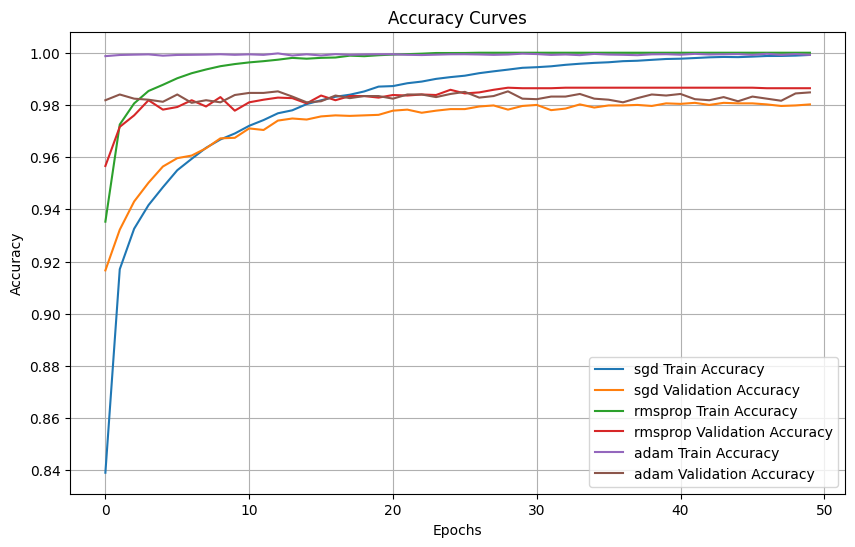

In [ ]:
import matplotlib.pyplot as plt

# Accuracy curve comparison
plt.figure(figsize=(10, 6))
for opt in optimizers:
    plt.plot(results[opt]['history'].history['accuracy'], label=f'{opt} Train Accuracy')
    plt.plot(results[opt]['history'].history['val_accuracy'], label=f'{opt} Validation Accuracy')

plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

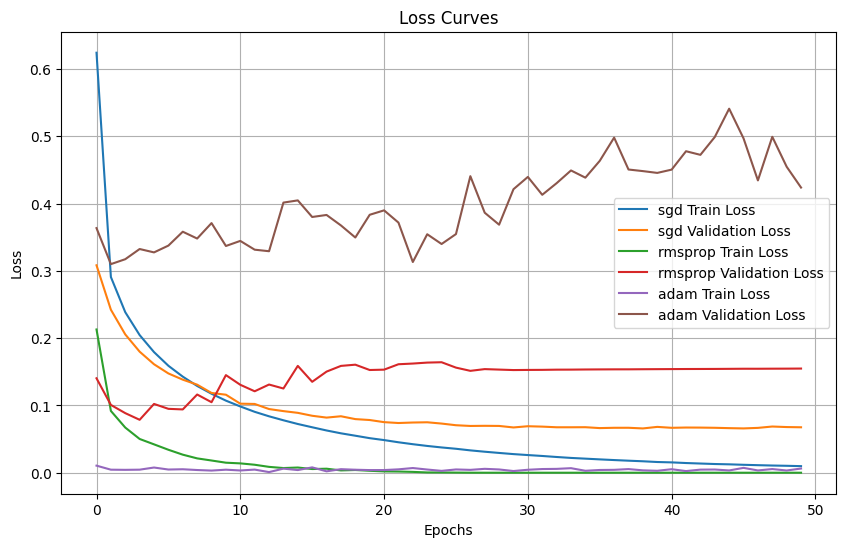

In [ ]:
import matplotlib.pyplot as plt

# Loss curve comparison
plt.figure(figsize=(10, 6))
for opt in optimizers:
    plt.plot(results[opt]['history'].history['loss'], label=f'{opt} Train Loss')
    plt.plot(results[opt]['history'].history['val_loss'], label=f'{opt} Validation Loss')

plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()